# Optimization - Finding the Best Answer

## What is Optimization?

Optimization = find the input that gives the **best output**.

In ML:
- **Best** = minimum error (loss)
- **Input** = model parameters (weights)
- **Method** = gradient descent

### The Big Picture

| Concept | Think of it as | Used in |
|---------|---------------|----------|
| Loss Function | How wrong the model is | Measuring performance |
| Gradient Descent | Roll a ball downhill | Training every ML model |
| Learning Rate | Step size | Controlling training speed |
| SGD | Use random mini-batches | Training large models |
| Convexity | One valley vs many valleys | Guaranteed vs local minimum |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

---
## 1. Loss Functions (How Wrong Are We?)

A loss function measures how bad the model's predictions are.

### Common Loss Functions:

| Loss | Formula | Used For |
|------|---------|----------|
| MSE | `(pred - actual)^2` | Regression (predicting numbers) |
| MAE | `|pred - actual|` | Regression (robust to outliers) |
| Cross-Entropy | `-sum(y * log(p))` | Classification (predicting categories) |

### Goal: Find weights that MINIMIZE the loss.

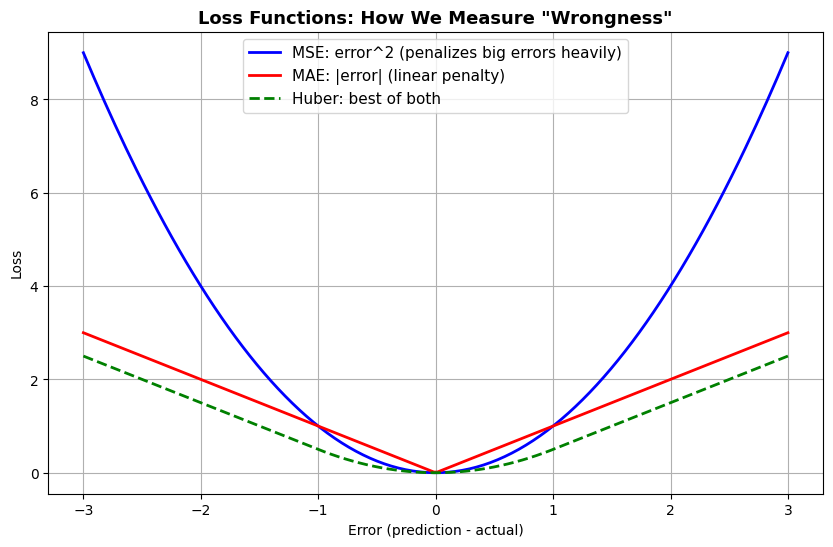

Key insight: All loss functions are 0 when error = 0 (perfect prediction)
They differ in how they penalize errors:
  MSE: big errors hurt A LOT (quadratic)
  MAE: all errors hurt equally (linear)
  Huber: like MSE for small errors, like MAE for big errors


In [2]:
errors = np.linspace(-3, 3, 200)

mse = errors**2
mae = np.abs(errors)
huber = np.where(np.abs(errors) < 1, 0.5 * errors**2, np.abs(errors) - 0.5)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(errors, mse, 'b-', linewidth=2, label='MSE: error^2 (penalizes big errors heavily)')
ax.plot(errors, mae, 'r-', linewidth=2, label='MAE: |error| (linear penalty)')
ax.plot(errors, huber, 'g--', linewidth=2, label='Huber: best of both')
ax.set_title('Loss Functions: How We Measure "Wrongness"', fontsize=13, fontweight='bold')
ax.set_xlabel('Error (prediction - actual)')
ax.set_ylabel('Loss')
ax.legend(fontsize=11)
plt.show()

print("Key insight: All loss functions are 0 when error = 0 (perfect prediction)")
print("They differ in how they penalize errors:")
print("  MSE: big errors hurt A LOT (quadratic)")
print("  MAE: all errors hurt equally (linear)")
print("  Huber: like MSE for small errors, like MAE for big errors")

---
## 2. Gradient Descent Variants

### The core algorithm:
```
w = w - learning_rate * gradient(loss, w)
```

### Three flavors:

| Variant | Uses | Pros | Cons |
|---------|------|------|------|
| Batch GD | All data | Stable | Slow for big data |
| Stochastic GD | One sample | Fast, escapes local min | Noisy |
| Mini-batch GD | Small batch | Best of both | Most popular |

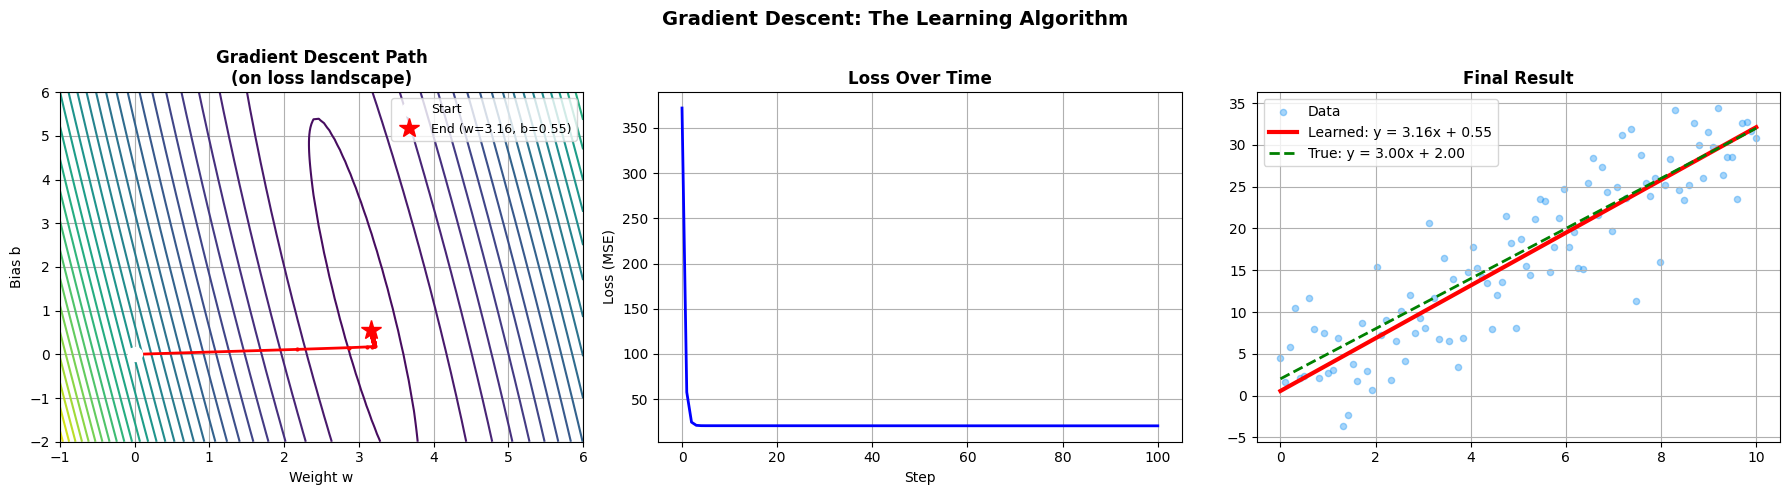

True: w=3.00, b=2.00
Learned: w=3.16, b=0.55
Final loss: 20.46


In [3]:
np.random.seed(42)

x = np.linspace(0, 10, 100)
y_true = 3 * x + 2
y_noisy = y_true + np.random.normal(0, 5, len(x))

def loss(w, b):
    return np.mean((w * x + b - y_noisy) ** 2)

def grad_w(w, b):
    return 2 * np.mean((w * x + b - y_noisy) * x)

def grad_b(w, b):
    return 2 * np.mean(w * x + b - y_noisy)

w, b = 0.0, 0.0
lr = 0.01
history = [(w, b, loss(w, b))]

for _ in range(100):
    w -= lr * grad_w(w, b)
    b -= lr * grad_b(w, b)
    history.append((w, b, loss(w, b)))

history = np.array(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

w_range = np.linspace(-1, 6, 100)
b_range = np.linspace(-2, 6, 100)
W, B = np.meshgrid(w_range, b_range)
L = np.array([[loss(wi, bi) for wi in w_range] for bi in b_range])

axes[0].contour(W, B, L, levels=30, cmap='viridis')
axes[0].plot(history[:, 0], history[:, 1], 'r.-', linewidth=2, markersize=4)
axes[0].plot(history[0, 0], history[0, 1], 'wo', markersize=10, label='Start')
axes[0].plot(history[-1, 0], history[-1, 1], 'r*', markersize=15, label=f'End (w={history[-1,0]:.2f}, b={history[-1,1]:.2f})')
axes[0].set_title('Gradient Descent Path\n(on loss landscape)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Weight w')
axes[0].set_ylabel('Bias b')
axes[0].legend(fontsize=9)

axes[1].plot(history[:, 2], 'b-', linewidth=2)
axes[1].set_title('Loss Over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss (MSE)')

axes[2].scatter(x, y_noisy, alpha=0.4, s=20, c='#2196F3', label='Data')
axes[2].plot(x, w * x + b, 'r-', linewidth=3, label=f'Learned: y = {w:.2f}x + {b:.2f}')
axes[2].plot(x, y_true, 'g--', linewidth=2, label='True: y = 3.00x + 2.00')
axes[2].set_title('Final Result', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)

plt.suptitle('Gradient Descent: The Learning Algorithm', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"True: w=3.00, b=2.00")
print(f"Learned: w={w:.2f}, b={b:.2f}")
print(f"Final loss: {loss(w, b):.2f}")

---
## 3. Convex vs Non-Convex (One Valley vs Many)

### Convex = one global minimum
- Like a bowl: no matter where you start, gradient descent finds the bottom
- Linear regression is convex

### Non-Convex = many local minima
- Like a mountain range: gradient descent might get stuck in a small valley
- Neural networks are non-convex

### Why it matters:
- Convex: guaranteed to find best answer
- Non-convex: might find a good-but-not-perfect answer

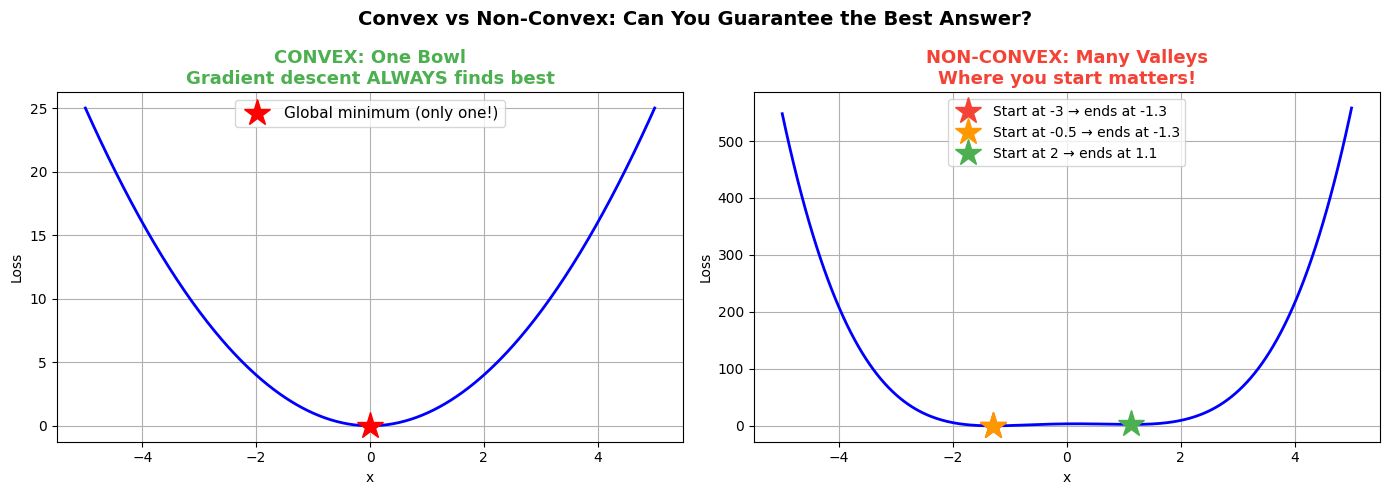

Convex (left): One valley. Start anywhere, roll to bottom. Done.
Non-convex (right): Many valleys. Different starts → different answers.

Neural networks are non-convex → that's why initialization matters!


In [4]:
x = np.linspace(-5, 5, 300)

convex = x**2
nonconvex = x**4 - 3*x**2 + x + 3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, convex, 'b-', linewidth=2)
axes[0].plot(0, 0, 'r*', markersize=20, label='Global minimum (only one!)')
axes[0].set_title('CONVEX: One Bowl\nGradient descent ALWAYS finds best', fontsize=13, fontweight='bold', color='#4CAF50')
axes[0].legend(fontsize=11)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Loss')

minima_x = []
for x0 in [-3, -0.5, 2]:
    xc = x0
    for _ in range(200):
        grad = 4*xc**3 - 6*xc + 1
        xc = xc - 0.01 * grad
    minima_x.append(xc)

axes[1].plot(x, nonconvex, 'b-', linewidth=2)
colors_gd = ['#F44336', '#FF9800', '#4CAF50']
starts = [-3, -0.5, 2]
for xc, col, s in zip(minima_x, colors_gd, starts):
    axes[1].plot(xc, xc**4 - 3*xc**2 + xc + 3, '*', color=col, markersize=20,
                 label=f'Start at {s} → ends at {xc:.1f}')

axes[1].set_title('NON-CONVEX: Many Valleys\nWhere you start matters!', fontsize=13, fontweight='bold', color='#F44336')
axes[1].legend(fontsize=10)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Loss')

plt.suptitle('Convex vs Non-Convex: Can You Guarantee the Best Answer?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Convex (left): One valley. Start anywhere, roll to bottom. Done.")
print("Non-convex (right): Many valleys. Different starts → different answers.")
print("\nNeural networks are non-convex → that's why initialization matters!")

---
## 4. SGD with Mini-Batches (How Real Models Train)

Real datasets have millions of samples. Computing gradient over ALL data is expensive.

### Solution: **Mini-batch Stochastic Gradient Descent**

- Instead of all data, use a random **batch** (e.g., 32 samples)
- Gradient is noisier but much faster
- Noise actually helps escape local minima!

### The training loop:
```python
for epoch in range(num_epochs):
    for batch in random_batches(data, batch_size):
        gradient = compute_gradient(batch, weights)
        weights -= learning_rate * gradient
```

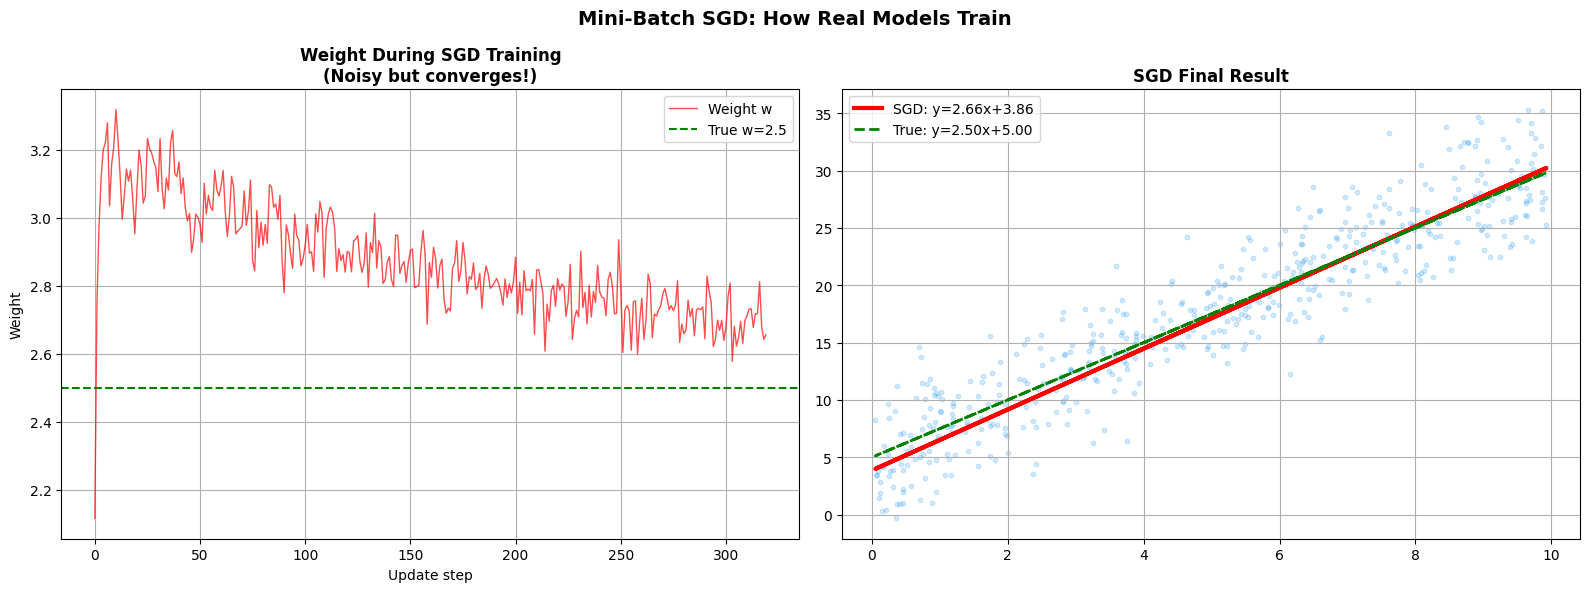

True: w=2.50, b=5.00
SGD found: w=2.66, b=3.86
Note: The path is noisy but it converges to the right answer!


In [5]:
np.random.seed(42)

x = np.random.uniform(0, 10, 500)
y = 2.5 * x + 5 + np.random.normal(0, 3, 500)

def sgd(x, y, lr=0.01, batch_size=32, epochs=30):
    w, b = 0.0, 0.0
    n = len(x)
    history = []
    for epoch in range(epochs):
        indices = np.random.permutation(n)
        for i in range(0, n, batch_size):
            idx = indices[i:i+batch_size]
            xb, yb = x[idx], y[idx]
            pred = w * xb + b
            dw = 2 * np.mean((pred - yb) * xb)
            db = 2 * np.mean(pred - yb)
            w -= lr * dw
            b -= lr * db
            history.append((w, b))
    return w, b, np.array(history)

w_sgd, b_sgd, path = sgd(x, y, lr=0.01, batch_size=32, epochs=20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(range(len(path)), path[:, 0], 'r-', linewidth=1, alpha=0.7, label='Weight w')
axes[0].axhline(y=2.5, color='g', linestyle='--', label='True w=2.5')
axes[0].set_title('Weight During SGD Training\n(Noisy but converges!)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Update step')
axes[0].set_ylabel('Weight')
axes[0].legend()

axes[1].scatter(x, y, alpha=0.2, s=10, c='#2196F3')
axes[1].plot(x, w_sgd * x + b_sgd, 'r-', linewidth=3, label=f'SGD: y={w_sgd:.2f}x+{b_sgd:.2f}')
axes[1].plot(x, 2.5*x+5, 'g--', linewidth=2, label='True: y=2.50x+5.00')
axes[1].set_title('SGD Final Result', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Mini-Batch SGD: How Real Models Train', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"True: w=2.50, b=5.00")
print(f"SGD found: w={w_sgd:.2f}, b={b_sgd:.2f}")
print("Note: The path is noisy but it converges to the right answer!")

---
## 5. Learning Rate Schedules

### Problem: One learning rate for the whole training is suboptimal.

### Solution: Start fast, then slow down.

| Schedule | How | When to Use |
|----------|-----|-------------|
| Constant | Same lr always | Simple problems |
| Step decay | Drop lr every N epochs | Common baseline |
| Exponential | lr *= decay_rate each epoch | Smooth decrease |
| Cosine | Smooth S-curve | Modern deep learning |

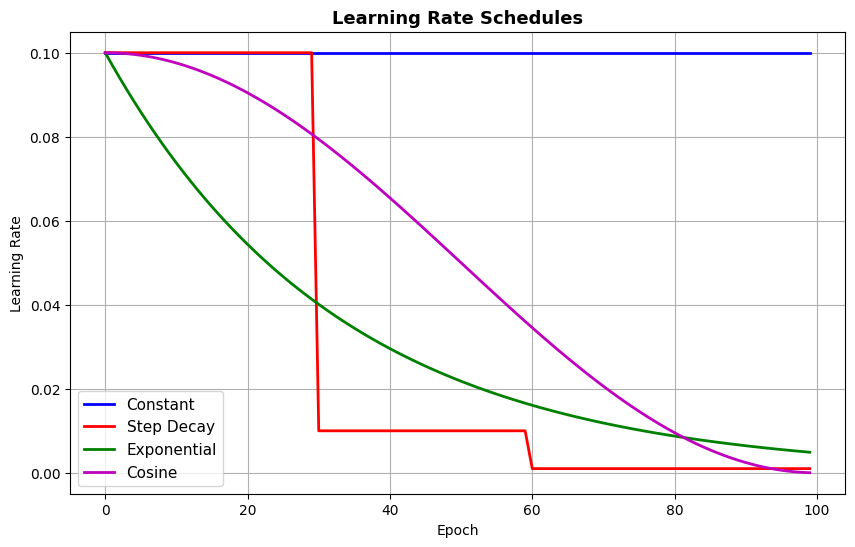

Start with big steps (explore), end with small steps (refine).
Cosine schedule is the most popular in modern deep learning.


In [6]:
epochs = np.arange(0, 100)
lr_init = 0.1

constant = np.full_like(epochs, lr_init, dtype=float)
step = np.where(epochs < 30, lr_init, np.where(epochs < 60, lr_init/10, lr_init/100))
exponential = lr_init * (0.97 ** epochs)
cosine = lr_init * 0.5 * (1 + np.cos(np.pi * epochs / len(epochs)))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs, constant, 'b-', linewidth=2, label='Constant')
ax.plot(epochs, step, 'r-', linewidth=2, label='Step Decay')
ax.plot(epochs, exponential, 'g-', linewidth=2, label='Exponential')
ax.plot(epochs, cosine, 'm-', linewidth=2, label='Cosine')
ax.set_title('Learning Rate Schedules', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.legend(fontsize=11)
plt.show()

print("Start with big steps (explore), end with small steps (refine).")
print("Cosine schedule is the most popular in modern deep learning.")

---
## 6. Putting It All Together: The Complete Training Loop

Everything you've learned connects here:

```
Linear Algebra:  data as matrices, model as matrix multiply
Calculus:        gradients tell you which direction to adjust
Statistics:      loss function measures how wrong you are
Optimization:    gradient descent finds the best weights
```

### The universal ML training loop:
```python
for epoch in range(epochs):
    # 1. Forward pass (linear algebra)
    predictions = X @ weights
    
    # 2. Compute loss (statistics)
    loss = mean((predictions - y) ** 2)
    
    # 3. Compute gradient (calculus)
    gradient = 2 * X.T @ (predictions - y) / n
    
    # 4. Update weights (optimization)
    weights -= learning_rate * gradient
```

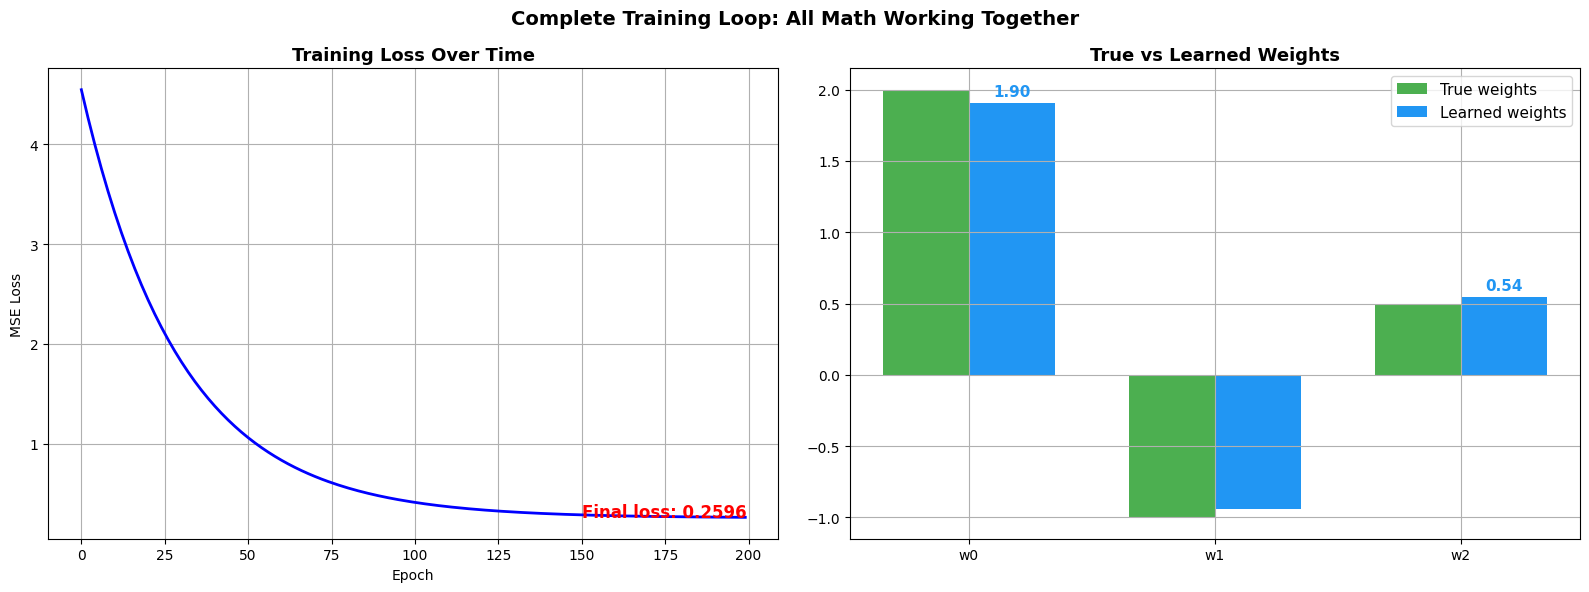

True weights:      [ 2.  -1.   0.5]
Learned weights:   [ 1.9034 -0.9385  0.5441]

Final MSE loss: 0.2596

The model discovered the true weights from noisy data!
This is Machine Learning.


In [7]:
np.random.seed(42)

n_samples = 200
n_features = 3
X = np.random.randn(n_samples, n_features)
true_w = np.array([2.0, -1.0, 0.5])
y = X @ true_w + np.random.normal(0, 0.5, n_samples)

weights = np.zeros(n_features)
lr = 0.01
losses = []

for epoch in range(200):
    predictions = X @ weights
    error = predictions - y
    loss = np.mean(error ** 2)
    gradient = 2 * X.T @ error / n_samples
    weights -= lr * gradient
    losses.append(loss)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(losses, 'b-', linewidth=2)
axes[0].set_title('Training Loss Over Time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].annotate(f'Final loss: {losses[-1]:.4f}', xy=(150, losses[-1]),
                 fontsize=12, color='red', fontweight='bold')

x_pos = np.arange(n_features)
width = 0.35
axes[1].bar(x_pos - width/2, true_w, width, label='True weights', color='#4CAF50')
axes[1].bar(x_pos + width/2, weights, width, label='Learned weights', color='#2196F3')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'w{i}' for i in range(n_features)])
axes[1].set_title('True vs Learned Weights', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)

for i in range(n_features):
    axes[1].text(x_pos[i] + width/2, weights[i] + 0.05, f'{weights[i]:.2f}',
                 ha='center', fontsize=11, fontweight='bold', color='#2196F3')

plt.suptitle('Complete Training Loop: All Math Working Together', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('True weights:     ', true_w)
print(f'Learned weights:   {weights.round(4)}')
print(f'\nFinal MSE loss: {losses[-1]:.4f}')
print('\nThe model discovered the true weights from noisy data!')
print('This is Machine Learning.')

---
## 7. Summary: How All Math Connects

```
┌──────────────────────────────────────────────────────────────┐
│                    MACHINE LEARNING                          │
│                                                              │
│  Data (X, y)                                                 │
│     │                                                        │
│     ▼                                                        │
│  Model: pred = X @ w          ← LINEAR ALGEBRA              │
│     │                                                        │
│     ▼                                                        │
│  Loss: mean((pred - y)^2)     ← STATISTICS                  │
│     │                                                        │
│     ▼                                                        │
│  Gradient: 2X^T(pred - y)/n  ← CALCULUS                     │
│     │                                                        │
│     ▼                                                        │
│  Update: w -= lr * gradient   ← OPTIMIZATION                │
│     │                                                        │
│     └──→ repeat until loss stops decreasing                  │
└──────────────────────────────────────────────────────────────┘
```

### You now know ALL the math behind ML. Congratulations!

### Next Steps:
1. Re-do all notebooks and exercises
2. Watch **3Blue1Brown** (Linear Algebra + Calculus playlists)
3. Start building simple ML models with scikit-learn
4. Then move to deep learning with PyTorch